<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/PRATICAL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)

df["Diagnosis"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Standardized Successfully")

Data Standardized Successfully


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (569, 30)
Reduced Shape: (569, 2)


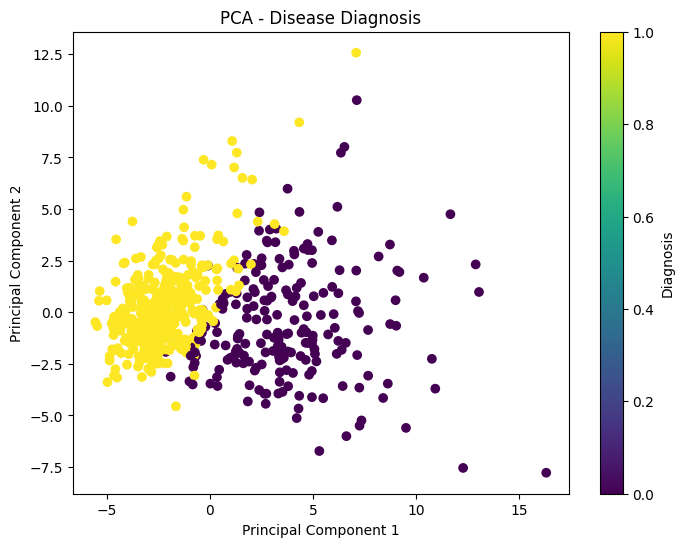

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Disease Diagnosis")

plt.colorbar(label="Diagnosis")

plt.show()

In [ ]:
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.44272026 0.18971182]


In [ ]:
lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X_scaled, y)

print("Original Shape:", X.shape)
print("LDA Shape:", X_lda.shape)

Original Shape: (569, 30)
LDA Shape: (569, 1)


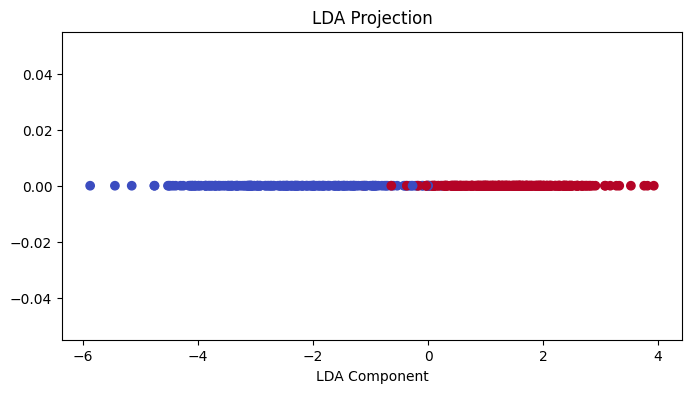

In [ ]:
plt.figure(figsize=(8,4))

plt.scatter(
    X_lda,
    np.zeros_like(X_lda),
    c=y,
    cmap='coolwarm'
)

plt.xlabel("LDA Component")
plt.title("LDA Projection")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Coefficient": lda.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
20,worst radius,-17.803522
0,mean radius,14.483357
2,mean perimeter,-10.886578
23,worst area,10.865680
5,mean compactness,4.208098
10,radius error,-2.276356
3,mean area,-2.110879
6,mean concavity,-2.103283
16,concavity error,2.031179
7,mean concave points,-1.568463


In [ ]:
print("PCA Components:", X_pca.shape[1])
print("LDA Components:", X_lda.shape[1])

PCA Components: 2
LDA Components: 1


In [ ]:
print("""
Experiment Completed Successfully.

✓ Patient dataset loaded
✓ Data standardized
✓ PCA applied for feature extraction
✓ LDA applied for feature selection
✓ Important medical parameters identified
✓ Disease diagnosis visualization completed
""")


Experiment Completed Successfully.

✓ Patient dataset loaded
✓ Data standardized
✓ PCA applied for feature extraction
✓ LDA applied for feature selection
✓ Important medical parameters identified
✓ Disease diagnosis visualization completed

